In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import time
import matplotlib.pyplot as plt
import matplotlib as mpl
import argparse
import json

from src.data.place_cells import PlaceCells
from src.data.trajectory_generator import TrajectoryGenerator
from src.model import RNN, MultilayerPCN, TemporalPCN, HierarchicalPCN
from src.trainer import Trainer, PCTrainer
from src.visualize import *
from src.evaluation.scores import circle_mask
import src.utils as utils
# from pypalettes import load_cmap

import pandas as pd
import seaborn as sns

## Gird map symmetry as a result of transitioning

Compare two things:

1. Training in trapezoid from scratch
2. Training in square and then continue training in trapezoid.

What are the differences in the score/scale etc.? (this is because Krupic only studied 2, but not 1.)

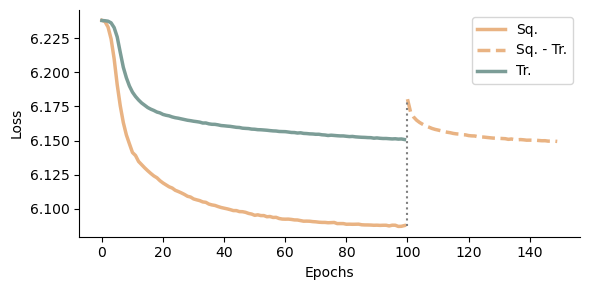

In [2]:
sq2tr_path = 'Apr-10-2025-22-51-22'
tr2sq_path = 'Apr-10-2025-23-28-15'
tr_path = 'Apr-10-2025-18-08-32'
sq_path = 'Apr-10-2025-16-13-23'
# sq_path = 'Mar-24-2025-10-48-57'
sq_loss = np.load(os.path.join('../results/tpc', sq_path, 'loss.npy'))
tr_loss = np.load(os.path.join('../results/tpc', tr_path, 'loss.npy'))
sq2tr_loss = np.load(os.path.join('../results/tpc', sq2tr_path, 'loss.npy'))
tr2sq_loss = np.load(os.path.join('../results/tpc', tr2sq_path, 'loss.npy'))
sq2tr_overall_loss = np.concatenate((sq_loss, sq2tr_loss))
tr2sq_overall_loss = np.concatenate((tr_loss, tr2sq_loss))

fig, ax = plt.subplots(figsize=(6,3))
ax.spines[['right', 'top']].set_visible(False)
plt.plot(np.arange(100), sq_loss, color="#e9b383", label='Sq.', lw=2.5)
plt.plot(np.arange(100, 150), sq2tr_loss, color="#e9b383", ls='--', label='Sq. - Tr.', lw=2.5)
plt.vlines(x=100, ymin=sq_loss[-1], ymax=sq2tr_loss[0], color='gray', linestyle=':')
plt.plot(np.arange(100), tr_loss, color="#7c9d97", label='Tr.', lw=2.5)
# plt.plot(np.arange(100, 150), tr2sq_loss, color="#7c9d97", ls='--', label='Tr. - Sq.', lw=2)
# plt.vlines(x=100, ymin=tr_loss[-1], ymax=tr2sq_loss[0], color='gray', linestyle=':')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.tight_layout()
plt.savefig(os.path.join('../results/trapezoid', 'loss.pdf'))
plt.show()

In [26]:
class Options:
    pass
res = 30
def recover_order(idx, array):
    original = np.zeros_like(array)
    original[idx] = array
    return original

def get_individual_metrics(rate_map, n_cells=32, w=1.6, h=1.6, size_threshold=0.5, scale_method='average'):
    # grid scores for half of the fields
    options = Options()
    options.box_width, options.box_height = w, h
    idx, _, _ = compute_grid_scores(res, rate_map, options, half=False)
    idx = idx[:n_cells]
    field_height = rate_map.shape[-1]
    left_idx, left_scores, left_sacs = compute_grid_scores(
        res, rate_map[:, :, :field_height // 2], options, half=True
    )
    right_idx, right_scores, right_sacs = compute_grid_scores(
        res, rate_map[:, :, field_height // 2:], options, half=True
    )
    
    # recover original order of indices unsorted by grid scores
    left_scores = recover_order(left_idx, left_scores)
    right_scores = recover_order(right_idx, right_scores)

    left_sacs = recover_order(left_idx, left_sacs)
    right_sacs = recover_order(right_idx, right_sacs)

    # get metrics from sacs
    left_metrics = [
        compute_grid_metrics(
            left_sac, env_size=w, size_thresh_scaler=size_threshold, scale_method=scale_method
        ) for left_sac in left_sacs
    ]
    right_metrics = [
        compute_grid_metrics(
            right_sac, env_size=w, size_thresh_scaler=size_threshold, scale_method=scale_method
        ) for right_sac in right_sacs
    ]
    
    # select cells with highest scores on full map
    # left_scores = left_scores[idx]
    # right_scores = right_scores[idx]
    # left_metrics = [left_metrics[i] for i in idx]
    # right_metrics = [right_metrics[i] for i in idx]
    return left_scores, left_metrics, right_scores, right_metrics, idx

In [27]:
tr_maps = np.load(os.path.join("../results/tpc", tr_path, "grid_maps.npy"))
sq_maps = np.load(os.path.join("../results/tpc", sq_path, "grid_maps.npy"))
sq2tr_maps = np.load(os.path.join("../results/tpc", sq2tr_path, "grid_maps.npy"))
tr2sq_maps = np.load(os.path.join("../results/tpc", tr2sq_path, "grid_maps.npy"))

In [28]:
sq_left_scores, sq_left_metrics, sq_right_scores, sq_right_metrics, sq_idx = get_individual_metrics(
    sq_maps, n_cells=32, w=1.6, h=1.6, size_threshold=0.5, scale_method='average'
)
tr_left_scores, tr_left_metrics, tr_right_scores, tr_right_metrics, tr_idx = get_individual_metrics(
    tr_maps, n_cells=32, w=1.6, h=3.2, size_threshold=0.5, scale_method='average'
)
sq2tr_left_scores, sq2tr_left_metrics, sq2tr_right_scores, sq2tr_right_metrics, sq2tr_idx = get_individual_metrics(
    sq2tr_maps, n_cells=32, w=1.6, h=3.2, size_threshold=0.5, scale_method='average'
)
# tr2sq_left_scores, tr2sq_left_metrics, tr2sq_right_scores, tr2sq_right_metrics, tr2sq_idx = get_individual_metrics(
#     tr2sq_maps, n_cells=32, w=1.6, h=1.6, size_threshold=0.5, scale_method='average'
# )

100%|██████████| 1024/1024 [00:19<00:00, 52.92it/s]


In [29]:
sq_left_scores, sq_right_scores = sq_left_scores[sq_idx], sq_right_scores[sq_idx]
tr_left_scores, tr_right_scores = tr_left_scores[tr_idx], tr_right_scores[tr_idx]
# sort sq2tr scores according to sq scores
sq2tr_left_scores, sq2tr_right_scores = sq2tr_left_scores[sq_idx], sq2tr_right_scores[sq_idx]

# metrics
sq_left_metrics = [sq_left_metrics[i] for i in sq_idx]
sq_right_metrics = [sq_right_metrics[i] for i in sq_idx]
tr_left_metrics = [tr_left_metrics[i] for i in tr_idx]
tr_right_metrics = [tr_right_metrics[i] for i in tr_idx]
sq2tr_left_metrics = [sq2tr_left_metrics[i] for i in sq_idx]
sq2tr_right_metrics = [sq2tr_right_metrics[i] for i in sq_idx]

In [30]:
sq_left_grid_sizes = np.array([grid_metrics['grid_size_meters'] for grid_metrics in sq_left_metrics])
sq_right_grid_sizes = np.array([grid_metrics['grid_size_meters'] for grid_metrics in sq_right_metrics])
sq_left_grid_scales = np.array([grid_metrics['grid_scale_meters'] for grid_metrics in sq_left_metrics])
sq_right_grid_scales = np.array([grid_metrics['grid_scale_meters'] for grid_metrics in sq_right_metrics])

tr_left_grid_sizes = np.array([grid_metrics['grid_size_meters'] for grid_metrics in tr_left_metrics])
tr_right_grid_sizes = np.array([grid_metrics['grid_size_meters'] for grid_metrics in tr_right_metrics])
tr_left_grid_scales = np.array([grid_metrics['grid_scale_meters'] for grid_metrics in tr_left_metrics])
tr_right_grid_scales = np.array([grid_metrics['grid_scale_meters'] for grid_metrics in tr_right_metrics])

sq2tr_left_grid_sizes = np.array([grid_metrics['grid_size_meters'] for grid_metrics in sq2tr_left_metrics])
sq2tr_right_grid_sizes = np.array([grid_metrics['grid_size_meters'] for grid_metrics in sq2tr_right_metrics])
sq2tr_left_grid_scales = np.array([grid_metrics['grid_scale_meters'] for grid_metrics in sq2tr_left_metrics])
sq2tr_right_grid_scales = np.array([grid_metrics['grid_scale_meters'] for grid_metrics in sq2tr_right_metrics])

In [31]:
sq_left_grid_sizes.mean(), sq_right_grid_sizes.mean(), sq2tr_left_grid_sizes.mean(), sq2tr_right_grid_sizes.mean(), tr_left_grid_sizes.mean(), tr_right_grid_sizes.mean()

(0.13754871719225029,
 0.13347232846084756,
 0.2643069154580484,
 0.3386189304109445,
 0.13495712659451023,
 0.14090894245638114)

In [32]:
sq_left_scores.mean(), sq_right_scores.mean(), sq2tr_left_scores.mean(), sq2tr_right_scores.mean(), tr_left_scores.mean(), tr_right_scores.mean()

(0.5886460377941063,
 0.7432179749488729,
 0.11592614049829458,
 -0.00883273434165346,
 0.7818502302954635,
 0.42115383894534897)

In [33]:
len(sq_right_scores)

32

In [12]:
rat_scores = {
    'sq2tr left': -0.3567415730337076,
    'sq2tr right': 0.2359550561797754,
    'sq left': 0.7078651685393258,
    'sq right': 0.6853932584269662,
}
rat_sizes = {
    'sq2tr left': 0.24202898550724633,
    'sq2tr right': 0.18937198067632852,
    'sq left': 0.18019323671497584,
    'sq right': 0.17198067632850242,

}

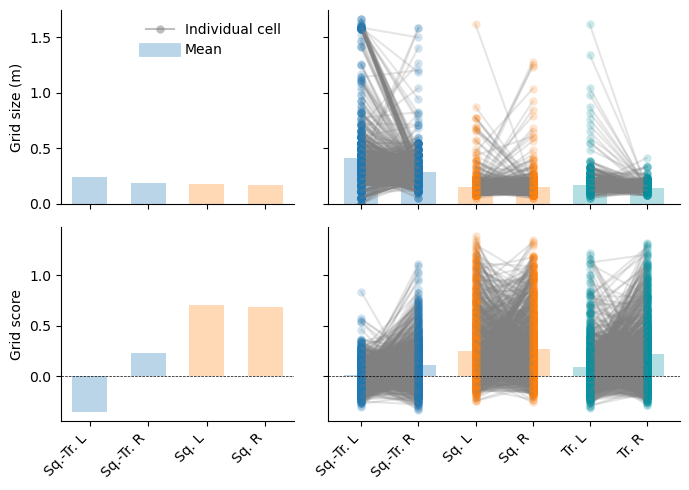

In [13]:
sns.set_style(None)
fig, ax = plt.subplots(2, 2, figsize=(7, 5), sharex='col', sharey='row', width_ratios=[0.66, 1])


ax[0, 0].spines[['right', 'top']].set_visible(False)
ax[1, 0].spines[['right', 'top']].set_visible(False)
ax[0, 0].bar(
    np.arange(len(rat_sizes)), list(rat_sizes.values()), color=['C0', 'C0', 'C1', 'C1'], edgecolor='None', alpha=0.3, width=0.6, align='center'
)
ax[0, 0].set_ylabel('Grid size (m)')
ax[1, 0].bar(
    np.arange(len(rat_scores)), list(rat_scores.values()), color=['C0', 'C0', 'C1', 'C1'], edgecolor='None', alpha=0.3, width=0.6, align='center'
)
ax[1, 0].set_xticks(
    np.arange(len(rat_scores)), ['Sq.-Tr. L', 'Sq.-Tr. R', 'Sq. L', 'Sq. R'], rotation=45, ha='right'
)
ax[1, 0].set_ylabel('Grid score')
ax[1, 0].axhline(0, color='k', lw=0.5, ls='--')

# Plot for Grid size
for left_size, right_size in zip(sq2tr_left_grid_sizes, sq2tr_right_grid_sizes):
    color = 'gray' if right_size > left_size else 'gray'
    ax[0, 1].plot([0, 1], [right_size, left_size], color=color, alpha=0.2, marker='o', markerfacecolor="C0", markeredgewidth=0)
for left_size, right_size in zip(sq_left_grid_sizes, sq_right_grid_sizes):
    color = 'gray' if right_size > left_size else 'gray'
    ax[0, 1].plot([2, 3], [right_size, left_size], color=color, alpha=0.2, marker='o', markerfacecolor="C1", markeredgewidth=0)
for left_size, right_size in zip(tr_left_grid_sizes, tr_right_grid_sizes):
    color = 'gray' if right_size > left_size else 'gray'
    ax[0, 1].plot([4, 5], [right_size, left_size], color=color, alpha=0.2, marker='o', markerfacecolor="#0593A2", markeredgewidth=0)
# plot mean of each group as bars
ax[0, 1].bar(0, sq2tr_right_grid_sizes.mean(), color="C0", edgecolor='None', alpha=0.3, width=0.6, align='center')
ax[0, 1].bar(1, sq2tr_left_grid_sizes.mean(), color="C0", edgecolor='None', alpha=0.3, width=0.6, align='center')
ax[0, 1].bar(2, sq_right_grid_sizes.mean(), color="C1", edgecolor='None', alpha=0.3, width=0.6, align='center')
ax[0, 1].bar(3, sq_left_grid_sizes.mean(), color="C1", edgecolor='None', alpha=0.3, width=0.6, align='center')
ax[0, 1].bar(4, tr_right_grid_sizes.mean(), color="#0593A2", edgecolor='None', alpha=0.3, width=0.6, align='center')
ax[0, 1].bar(5, tr_left_grid_sizes.mean(), color="#0593A2", edgecolor='None', alpha=0.3, width=0.6, align='center')


# Plot for Grid score
for left_score, right_score in zip(sq2tr_left_scores, sq2tr_right_scores):
    color = 'gray' if right_score > left_score else 'gray'
    ax[1, 1].plot([0, 1], [right_score, left_score], color=color, alpha=0.2, marker='o', markerfacecolor="C0", markeredgewidth=0)
for left_score, right_score in zip(sq_left_scores, sq_right_scores):
    color = 'gray' if right_score > left_score else 'gray'
    ax[1, 1].plot([2, 3], [right_score, left_score], color=color, alpha=0.2, marker='o', markerfacecolor="C1", markeredgewidth=0)
for left_score, right_score in zip(tr_left_scores, tr_right_scores):
    color = 'gray' if right_score > left_score else 'gray'
    ax[1, 1].plot([4, 5], [right_score, left_score], color=color, alpha=0.2, marker='o', markerfacecolor="#0593A2", markeredgewidth=0)
# plot mean of each group as short black line
ax[1, 1].bar(0, sq2tr_right_scores.mean(), edgecolor='none', color="C0", alpha=0.3, width=0.6, align='center')
ax[1, 1].bar(1, sq2tr_left_scores.mean(), edgecolor='none', color="C0", alpha=0.3, width=0.6, align='center')
ax[1, 1].bar(2, sq_right_scores.mean(), edgecolor='none', color="C1", alpha=0.3, width=0.6, align='center')
ax[1, 1].bar(3, sq_left_scores.mean(), edgecolor='none', color="C1", alpha=0.3, width=0.6, align='center')
ax[1, 1].bar(4, tr_right_scores.mean(), edgecolor='none', color="#0593A2", alpha=0.3, width=0.6, align='center')
ax[1, 1].bar(5, tr_left_scores.mean(), edgecolor='none', color="#0593A2", alpha=0.3, width=0.6, align='center')

ax[1, 1].set_xticks(
    [0, 1, 2, 3, 4, 5], 
    ['Sq.-Tr. L', 'Sq.-Tr. R', 'Sq. L', 'Sq. R', 'Tr. L', 'Tr. R'],
    rotation=45, ha='right'
)
ax[0, 1].spines[['right', 'top']].set_visible(False)
ax[0, 0].plot([None, None], [None, None], color='gray', alpha=0.5, marker='o', markerfacecolor='gray', markeredgewidth=0, label='Individual cell')
ax[0, 0].plot([], [], color='C0', alpha=0.3, label='Mean', lw=10)
ax[0, 0].legend(frameon=False)
# add a hline at y=0 for ax[1]
ax[1, 1].axhline(0, color='k', lw=0.5, ls='--')
ax[1, 1].spines[['right', 'top']].set_visible(False)
# plt.savefig(os.path.join('../results/trapezoid', 'grid_metrics.pdf'), bbox_inches='tight')
plt.tight_layout()
plt.show()

In [15]:
tr_map_srt = tr_maps[tr_idx]
sq_map_srt = sq_maps[sq_idx]
sq2tr_map_srt = sq2tr_maps[sq2tr_idx]

In [16]:
tr_scores_srt = np.load(os.path.join("../results/tpc", tr_path, "grid_scores.npy"))
sq_scores_srt = np.load(os.path.join("../results/tpc", sq_path, "grid_scores.npy"))
tr2sq_scores_srt = np.load(os.path.join("../results/tpc", tr2sq_path, "grid_scores.npy"))
sq2tr_scores_srt = np.load(os.path.join("../results/tpc", sq2tr_path, "grid_scores.npy"))

In [18]:
tr_left_scores_srt = np.load(os.path.join("../results/tpc", tr_path, "left_grid_scores.npy"))[tr_idx]
tr_right_scores_srt = np.load(os.path.join("../results/tpc", tr_path, "right_grid_scores.npy"))[tr_idx]
sq_left_scores_srt = np.load(os.path.join("../results/tpc", sq_path, "left_grid_scores.npy"))[sq_idx]
sq_right_scores_srt = np.load(os.path.join("../results/tpc", sq_path, "right_grid_scores.npy"))[sq_idx]
sq2tr_left_scores_srt = np.load(os.path.join("../results/tpc", sq2tr_path, "left_grid_scores.npy"))[sq2tr_idx]
sq2tr_right_scores_srt = np.load(os.path.join("../results/tpc", sq2tr_path, "right_grid_scores.npy"))[sq2tr_idx]

In [19]:
tr_sacs_srt = np.load(os.path.join("../results/tpc", tr_path, "sac.npy"))
sq_sacs_srt = np.load(os.path.join("../results/tpc", sq_path, "sac.npy"))
sq2tr_sacs_srt = np.load(os.path.join("../results/tpc", sq2tr_path, "sac.npy"))

In [20]:
tr_left_sacs_srt = np.load(os.path.join("../results/tpc", tr_path, "left_sac.npy"))[tr_idx]
tr_right_sacs_srt = np.load(os.path.join("../results/tpc", tr_path, "right_sac.npy"))[tr_idx]
sq_left_sacs_srt = np.load(os.path.join("../results/tpc", sq_path, "left_sac.npy"))[sq_idx]
sq_right_sacs_srt = np.load(os.path.join("../results/tpc", sq_path, "right_sac.npy"))[sq_idx]
sq2tr_left_sacs_srt = np.load(os.path.join("../results/tpc", sq2tr_path, "left_sac.npy"))[sq2tr_idx]
sq2tr_right_sacs_srt = np.load(os.path.join("../results/tpc", sq2tr_path, "right_sac.npy"))[sq2tr_idx]

In [21]:
def plot_rms(rms, h, w, res_h, res_w, scores, env_shape="rectangle"):
    fig, axes = plt.subplots(4, 8, figsize=(8, 4))

    for j, ax in enumerate(axes.flatten()):
        r = (rms[j] - rms[j].min()) / (rms[j].max() - rms[j].min() + 1e-8)
        # rotate the map by 180 degrees
        if env_shape == "trapezoid":
            r[~trapezoid_mask(h, w, res_h, res_w)] = np.nan
        r = np.rot90(r, 2)
        ax.imshow(r, cmap="jet", extent=[-h/2, h/2, -w/2, w/2], origin='lower')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{scores[j]:.2f}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def plot_sacs(sacs, h, w, scores):
    fig, axes = plt.subplots(4, 8, figsize=(8, 4))

    for j, ax in enumerate(axes.flatten()):
        sac = (sacs[j] - sacs[j].min()) / (sacs[j].max() - sacs[j].min() + 1e-8)
        sac = np.rot90(sac, 2)
        ax.imshow(sac, cmap="jet", extent=[-h/2, h/2, -w/2, w/2], origin='lower')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{scores[j]:.2f}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

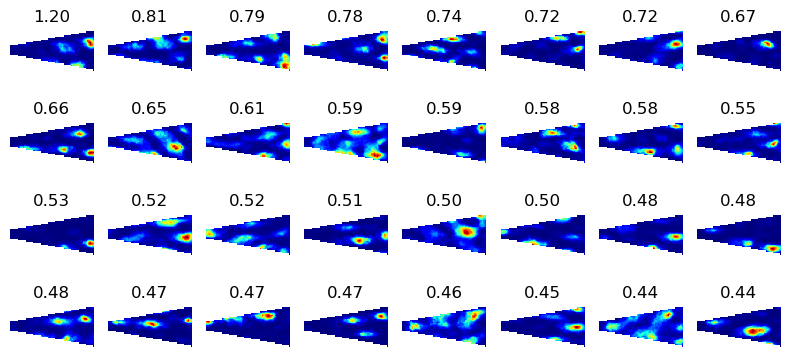

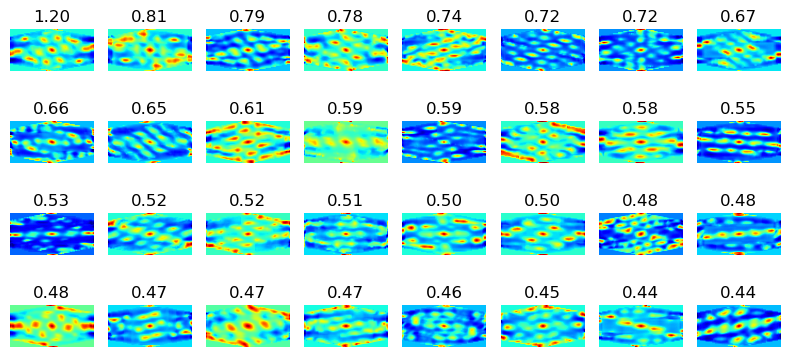

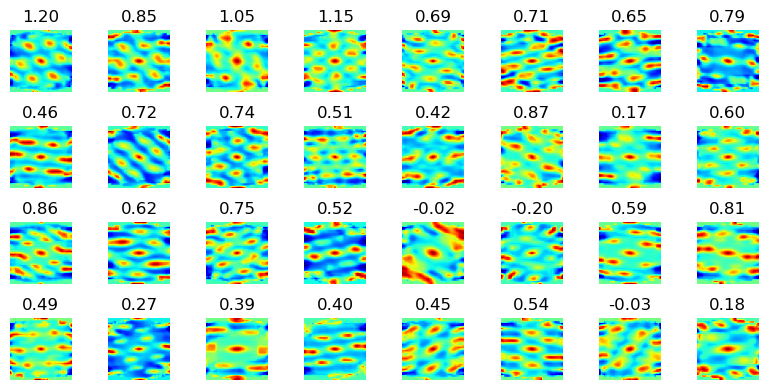

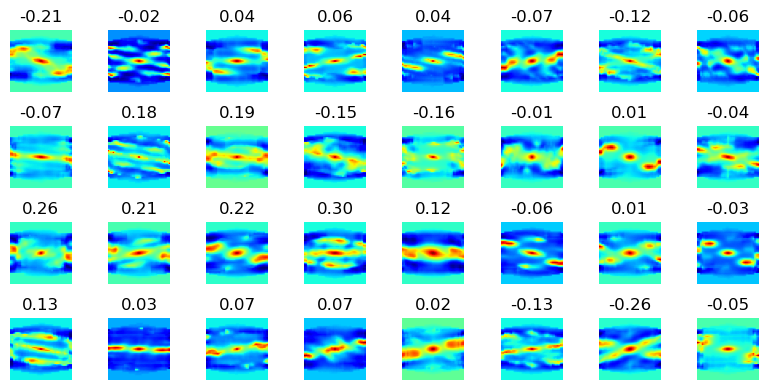

In [22]:
plot_rms(
    sq2tr_map_srt, 3.2, 1.6, 60, 30, sq2tr_scores_srt, env_shape="trapezoid"
)
plot_sacs(
    sq2tr_sacs_srt, 3.2, 1.6, sq2tr_scores_srt
)
plot_sacs(sq2tr_left_sacs_srt, 1.6, 1.6, sq2tr_left_scores_srt)
plot_sacs(sq2tr_right_sacs_srt, 1.6, 1.6, sq2tr_right_scores_srt)

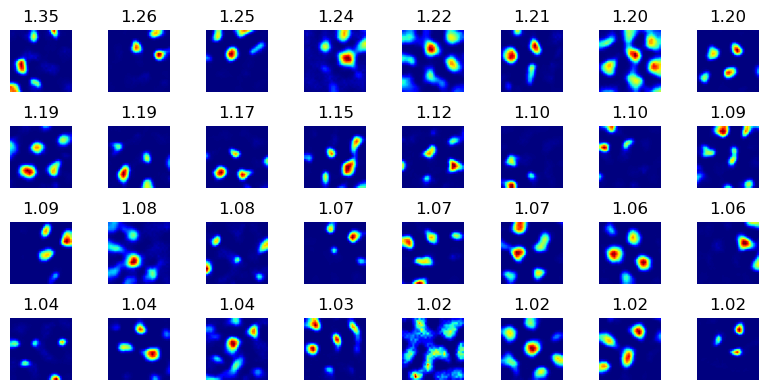

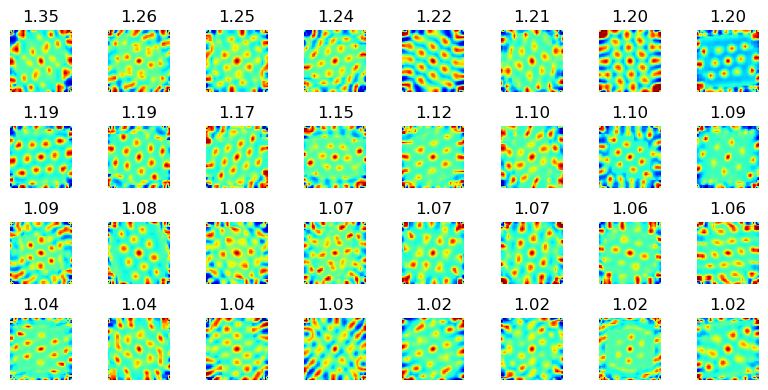

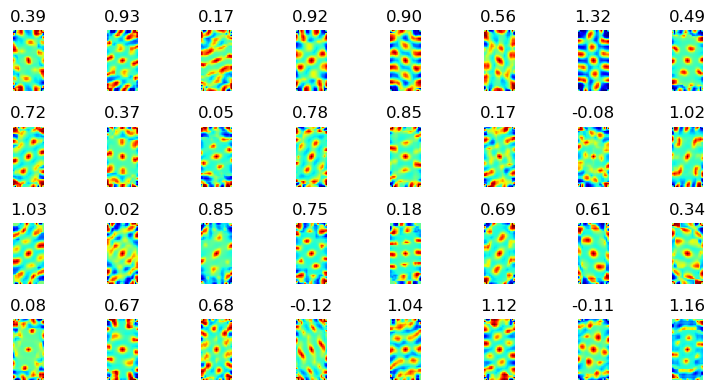

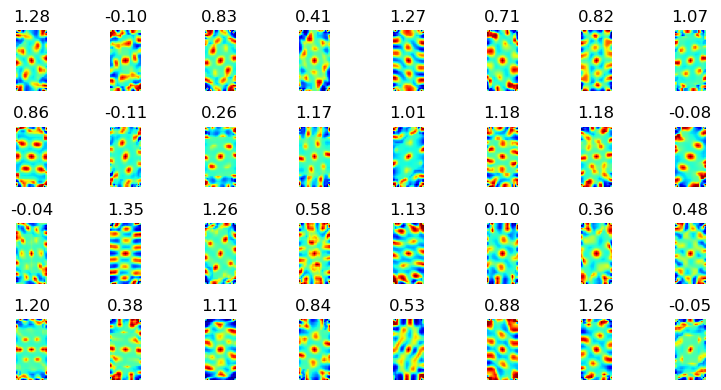

In [23]:
plot_rms(
    sq_map_srt, 1.6, 1.6, 30, 30, sq_scores_srt, env_shape="rectangle"
)
plot_sacs(
    sq_sacs_srt, 1.6, 1.6, sq_scores_srt
)
plot_sacs(sq_left_sacs_srt, 0.8, 1.6, sq_left_scores_srt)
plot_sacs(sq_right_sacs_srt, 0.8, 1.6, sq_right_scores_srt)

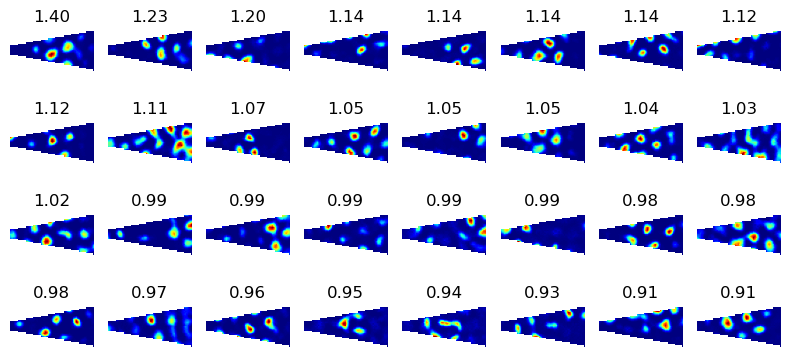

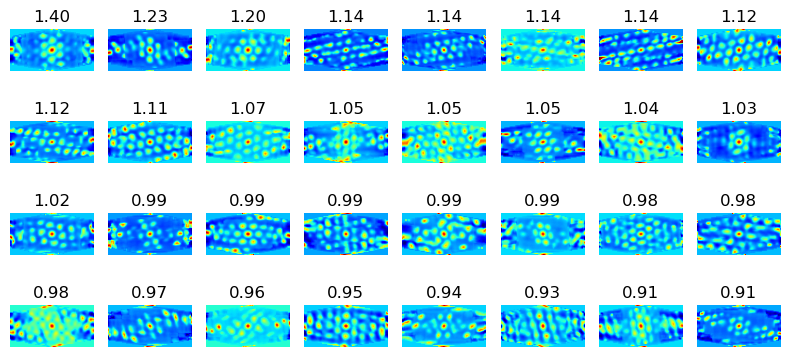

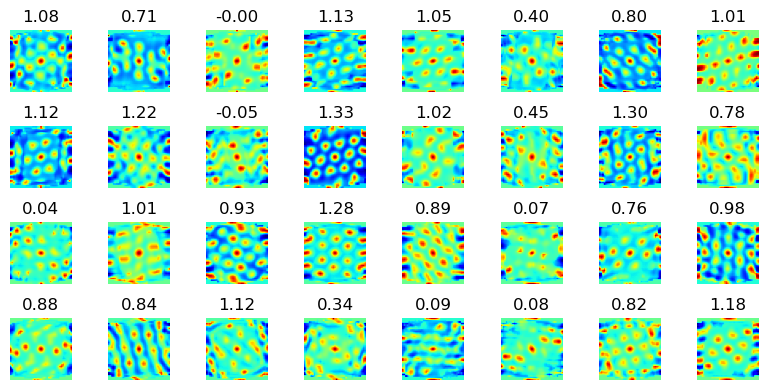

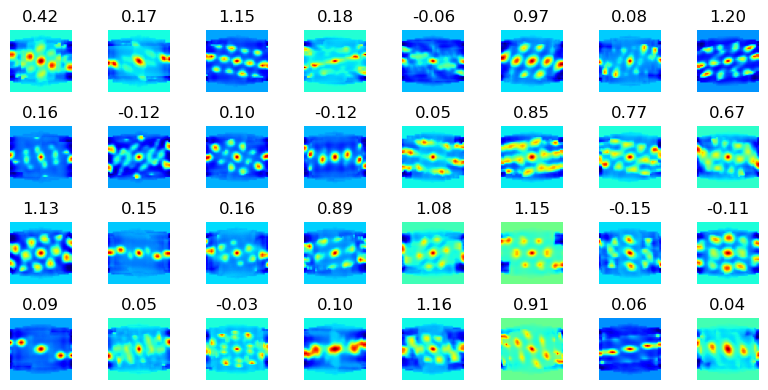

In [24]:
plot_rms(
    tr_map_srt, 3.2, 1.6, 60, 30, tr_scores_srt, env_shape="trapezoid"
)
plot_sacs(
    tr_sacs_srt, 3.2, 1.6, tr_scores_srt
)
plot_sacs(tr_left_sacs_srt, 1.6, 1.6, tr_left_scores_srt)
plot_sacs(tr_right_sacs_srt, 1.6, 1.6, tr_right_scores_srt)

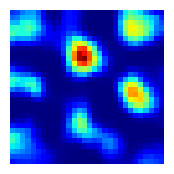

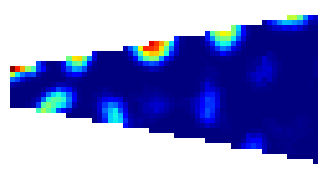

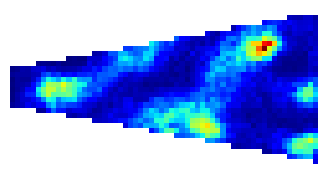

In [26]:
# sq_ind = 7
# tr_ind = 11
# sq2tr_ind = 4
# tr2sq_ind = 7
sq_ind = 4
tr_ind = 7
sq2tr_ind = 30
# tr2sq_ind = 18
rm_sq = sq_map_srt[sq_ind]
rm_sq = (rm_sq - rm_sq.min()) / (rm_sq.max() - rm_sq.min() + 1e-8)
rm_sq = np.rot90(rm_sq, 2)
rm_tr = tr_map_srt[tr_ind]
rm_tr = (rm_tr - rm_tr.min()) / (rm_tr.max() - rm_tr.min() + 1e-8)
rm_tr[~trapezoid_mask(3.2, 1.6, 60, 30)] = np.nan
rm_tr = np.rot90(rm_tr, 2)
rm_sq2tr = sq2tr_map_srt[sq2tr_ind]
rm_sq2tr = (rm_sq2tr - rm_sq2tr.min()) / (rm_sq2tr.max() - rm_sq2tr.min() + 1e-8)
rm_sq2tr[~trapezoid_mask(3.2, 1.6, 60, 30)] = np.nan
rm_sq2tr = np.rot90(rm_sq2tr, 2)
# rm_tr2sq = tr2sq_map_srt[tr2sq_ind]
# rm_tr2sq = (rm_tr2sq - rm_tr2sq.min()) / (rm_tr2sq.max() - rm_tr2sq.min() + 1e-8)
# rm_tr2sq = np.rot90(rm_tr2sq, 2)

plt.figure(figsize=(2, 2))
plt.imshow(rm_sq, cmap="jet", extent=[-1.6/2, 1.6/2, -1.6/2, 1.6/2], origin='lower')
plt.axis('off')
plt.savefig(os.path.join('../results/trapezoid', 'sq.pdf'), bbox_inches='tight')
# plt.title(f'{sq_scores_srt[sq_ind]:.2f}')

plt.figure(figsize=(4, 2))
plt.imshow(rm_tr, cmap="jet", extent=[-3.2/2, 3.2/2, -1.6/2, 1.6/2], origin='lower')
plt.axis('off')
plt.savefig(os.path.join('../results/trapezoid', 'tr.pdf'), bbox_inches='tight')
# plt.title(f'{tr_scores_srt[tr_ind]:.2f}')

# plt.figure(figsize=(2, 2))
# plt.imshow(rm_tr2sq, cmap="jet", extent=[-1.6/2, 1.6/2, -1.6/2, 1.6/2], origin='lower')
# plt.axis('off')
# plt.savefig(os.path.join('../results/trapezoid', 'tr2sq.pdf'), bbox_inches='tight')
# plt.title(f'{tr2sq_scores_srt[tr2sq_ind]:.2f}')

plt.figure(figsize=(4, 2))
plt.imshow(rm_sq2tr, cmap="jet", extent=[-3.2/2, 3.2/2, -1.6/2, 1.6/2], origin='lower')
plt.axis('off')
plt.savefig(os.path.join('../results/trapezoid', 'sq2tr.pdf'), bbox_inches='tight')
# plt.title(f'{sq2tr_scores_srt[sq2tr_ind]:.2f}')


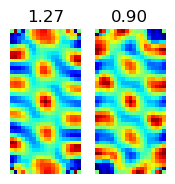

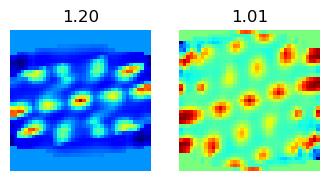

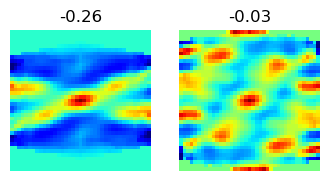

In [29]:
sq_sac_ind = 4
tr_sac_ind = 7
sq2tr_sac_ind = 30
tr2sq_sac_ind = 18

# sq_sac_ind = 7
# tr_sac_ind = 11
# sq2tr_sac_ind = 4
# tr2sq_sac_ind = 7

sq_right_sac = sq_right_sacs_srt[sq_sac_ind]
sq_right_sac = (sq_right_sac - sq_right_sac.min()) / (sq_right_sac.max() - sq_right_sac.min() + 1e-8)
sq_right_sac = np.flip(sq_right_sac, axis=1)
sq_left_sac = sq_left_sacs_srt[sq_sac_ind]
sq_left_sac = (sq_left_sac - sq_left_sac.min()) / (sq_left_sac.max() - sq_left_sac.min() + 1e-8)
sq_left_sac = np.flip(sq_left_sac, axis=1)

tr_right_sac = tr_right_sacs_srt[tr_sac_ind]
tr_right_sac = (tr_right_sac - tr_right_sac.min()) / (tr_right_sac.max() - tr_right_sac.min() + 1e-8)
tr_right_sac = np.flip(tr_right_sac, axis=1)
tr_left_sac = tr_left_sacs_srt[tr_sac_ind]
tr_left_sac = (tr_left_sac - tr_left_sac.min()) / (tr_left_sac.max() - tr_left_sac.min() + 1e-8)
tr_left_sac = np.flip(tr_left_sac, axis=1)

sq2tr_right_sac = sq2tr_right_sacs_srt[sq2tr_sac_ind]
sq2tr_right_sac = (sq2tr_right_sac - sq2tr_right_sac.min()) / (sq2tr_right_sac.max() - sq2tr_right_sac.min() + 1e-8)
sq2tr_right_sac = np.flip(sq2tr_right_sac, axis=1)
sq2tr_left_sac = sq2tr_left_sacs_srt[sq2tr_sac_ind]
sq2tr_left_sac = (sq2tr_left_sac - sq2tr_left_sac.min()) / (sq2tr_left_sac.max() - sq2tr_left_sac.min() + 1e-8)
sq2tr_left_sac = np.flip(sq2tr_left_sac, axis=1)
# tr2sq_right_sac = tr2sq_right_sacs_srt[tr2sq_sac_ind]
# tr2sq_right_sac = (tr2sq_right_sac - tr2sq_right_sac.min()) / (tr2sq_right_sac.max() - tr2sq_right_sac.min() + 1e-8)
# tr2sq_right_sac = np.flip(tr2sq_right_sac, axis=1)
# tr2sq_left_sac = tr2sq_left_sacs_srt[tr2sq_sac_ind]
# tr2sq_left_sac = (tr2sq_left_sac - tr2sq_left_sac.min()) / (tr2sq_left_sac.max() - tr2sq_left_sac.min() + 1e-8)
# tr2sq_left_sac = np.flip(tr2sq_left_sac, axis=1)

fig, ax = plt.subplots(1, 2, figsize=(2, 2))
ax[0].imshow(sq_right_sac, cmap="jet")
ax[0].set_title(f'{sq_right_scores_srt[sq_sac_ind]:.2f}')
ax[0].axis('off')
ax[1].imshow(sq_left_sac, cmap="jet")
ax[1].set_title(f'{sq_left_scores_srt[sq_sac_ind]:.2f}')
ax[1].axis('off')
plt.savefig(os.path.join('../results/trapezoid', 'sq_sac.pdf'), bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(4, 2))
ax[0].imshow(tr_right_sac, cmap="jet")
ax[0].set_title(f'{tr_right_scores_srt[tr_sac_ind]:.2f}')
ax[0].axis('off')
ax[1].imshow(tr_left_sac, cmap="jet")
ax[1].set_title(f'{tr_left_scores_srt[tr_sac_ind]:.2f}')
ax[1].axis('off')
plt.savefig(os.path.join('../results/trapezoid', 'tr_sac.pdf'), bbox_inches='tight')
plt.show()

# fig, ax = plt.subplots(1, 2, figsize=(2, 2))
# ax[0].imshow(tr2sq_right_sac, cmap="jet")
# ax[0].set_title(f'{tr2sq_right_scores_srt[tr2sq_sac_ind]:.2f}')
# ax[0].axis('off')
# ax[1].imshow(tr2sq_left_sac, cmap="jet")
# ax[1].set_title(f'{tr2sq_left_scores_srt[tr2sq_sac_ind]:.2f}')
# ax[1].axis('off')
# plt.savefig(os.path.join('../results/trapezoid', 'tr2sq_sac.pdf'), bbox_inches='tight')
# plt.show()

fig, ax = plt.subplots(1, 2, figsize=(4, 2))
ax[0].imshow(sq2tr_right_sac, cmap="jet")
ax[0].set_title(f'{sq2tr_right_scores_srt[sq2tr_sac_ind]:.2f}')
ax[0].axis('off')
ax[1].imshow(sq2tr_left_sac, cmap="jet")
ax[1].set_title(f'{sq2tr_left_scores_srt[sq2tr_sac_ind]:.2f}')
ax[1].axis('off')
plt.savefig(os.path.join('../results/trapezoid', 'sq2tr_sac.pdf'), bbox_inches='tight')
plt.show()
